# OffSide 2026 — Final Solution
**Target:** `scored_flag` | **Metric:** Average Precision (AP) | **Imbalance:** ~9.5% positive rate

In [27]:
# ==========================================================
# Imports and Global Configuration
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.metrics import average_precision_score

import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

SEED = 42
TARGET = "scored_flag"

print("Setup complete.")

Setup complete.


In [30]:
#Load the data and understand the target

train = pd.read_csv('/kaggle/input/datasets/abhinavpandey2005/official/train.csv', low_memory=False)
test  = pd.read_csv('/kaggle/input/datasets/abhinavpandey2005/official/test.csv', low_memory=False)

print(train.shape)
print(test.shape)

print("\nTarget distribution")
print(train[TARGET].value_counts())

print("\nTarget ratio")
print(train[TARGET].value_counts(normalize=True))

train.head()

(1319813, 64)
(565635, 63)

Target distribution
scored_flag
False    1207131
True      112682
Name: count, dtype: int64

Target ratio
scored_flag
False    0.914623
True     0.085377
Name: proportion, dtype: float64


,appearance_id,date,season,minutes_played,yellow_cards,red_cards,disciplinary_points,home_club_id,away_club_id,home_club_name,away_club_name,home_club_goals,away_club_goals,home_away,attendance,stadium,referee,name_x,country_name,competition_type,confederation,market_value_before_match,age,height_in_cm,foot,position,sub_position,country_of_citizenship,international_caps,international_goals,highest_market_value_in_eur,market_value_ratio,avg_xG,avg_xA,avg_shots,avg_key_passes,avg_xGChain,avg_xGBuildup,avg_npxG,has_understat,log_market_value,value_pct_of_peak,market_value_tier,minutes_ratio,full_match_flag,starter_flag,substitute_flag,scored_flag,card_flag,goal_diff_abs,age_bucket,prime_age_flag,veteran_flag,goal_per_cap,has_national_team_experience,xG_to_xA_ratio,finisher_flag,creative_player_flag,analytics_coverage_flag,is_goalkeeper,is_defender,is_midfielder,is_attacker,name_y
0,2335635_20137,2013-07-15,2013,90,0,0,0,6414,2783,Metalist Kharkiv (- 2016),Metalurg Donetsk (- 2015),1,0,HOME,28217.0,OSK Metalist,Vitaliy Godulyan,premier-liga,Ukraine,domestic_league,europa,9000000.0,40.9,181.0,right,Midfield,Attacking Midfield,Argentina,19.0,1.0,10000000.0,0.005000,0.732855,2.021390,24.0,24.0,4.417058,3.298448,0.732855,True,16.012735,0.900000,HIGH,1.000000,True,True,False,False,False,1,35+,False,True,0.052632,True,0.362550,False,True,True,False,False,True,False,José Sosa
1,2654328_36235,2016-03-07,2015,90,0,0,0,2700,4128,Anzhi Makhachkala ( -2022),Amkar Perm,0,1,AWAY,8100.0,Anzhi-Arena,Aleksey Matyunin,premier-liga,Russia,domestic_league,europa,700000.0,40.6,183.0,left,Defender,Centre-Back,Bulgaria,0.0,0.0,1000000.0,0.010000,0.765317,1.683399,17.6,16.2,2.867628,1.722578,0.614462,True,13.458837,0.700000,LOW,1.000000,True,True,False,False,False,1,35+,False,True,NaN,False,0.454626,False,True,True,False,True,False,False,Petar Zanev
2,4098806_1163778,2024-03-03,2023,63,0,0,0,1096,475,Royal Antwerp Football Club,Koninklijke Sint-Truidense Voetbalvereniging,3,0,AWAY,15500.0,De Bosuil,Kevin Van Damme,jupiler-pro-league,Belgium,domestic_league,europa,400000.0,24.0,193.0,right,Attack,Centre-Forward,United States,0.0,0.0,1500000.0,0.300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,12.899222,0.266667,LOW,0.700000,False,True,False,False,False,3,21-24,True,False,NaN,False,NaN,False,False,False,False,False,False,True,Kahveh Zahiroleslam
3,2700658_348863,2016-08-28,2016,33,2,0,2,383,202,Eindhovense Voetbalvereniging Philips Sport Ve...,Football Club Groningen,0,0,AWAY,33000.0,Philips Stadion,Bas Nijhuis,eredivisie,Netherlands,domestic_league,europa,800000.0,28.8,178.0,right,Midfield,Central Midfield,Curacao,47.0,13.0,5500000.0,0.309091,0.795000,1.396250,19.0,18.0,2.141775,1.103966,0.795000,True,13.592368,0.145455,LOW,0.366667,False,False,True,False,True,0,25-29,True,False,0.276596,True,0.569382,False,True,True,False,False,True,False,Juninho Bacuna
4,3016404_240551,2018-03-31,2017,65,0,0,0,4128,932,Amkar Perm,"Футбольный клуб ""Локомотив"" Москва",2,1,HOME,8837.0,RZD Arena,Sergey Lapochkin,premier-liga,Russia,domestic_league,europa,800000.0,32.0,189.0,left,Attack,Centre-Forward,Nigeria,0.0,0.0,2000000.0,0.125000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,13.592368,0.400000,LOW,0.722222,False,True,False,True,False,1,30-34,False,True,NaN,False,NaN,False,False,False,False,False,False,True,Aaron Olanare


In [31]:
# Cell 3 - First look at the data

# What types of columns do we have?
print("Column dtypes")
display(train.dtypes.value_counts())

# Which columns are objects?
obj_cols = train.select_dtypes(include="object").columns.tolist()

print("\nObject columns:")
print(obj_cols)

# Missing values
missing_df = (
train.isna()
.mean()
.sort_values(ascending=False)
.reset_index()
)

missing_df.columns = ["column", "missing_pct"]
print("\nColumns with missing values")
display(missing_df[missing_df["missing_pct"] > 0])

# Quick check of the first few rows
train.head()

Column dtypes


object     20
float64    20
bool       14
int64      10
Name: count, dtype: int64


Object columns:
['appearance_id', 'date', 'home_club_name', 'away_club_name', 'home_away', 'stadium', 'referee', 'name_x', 'country_name', 'competition_type', 'confederation', 'foot', 'position', 'sub_position', 'country_of_citizenship', 'has_understat', 'market_value_tier', 'age_bucket', 'analytics_coverage_flag', 'name_y']

Columns with missing values


,column,missing_pct
0,goal_per_cap,5.291894e-01
1,xG_to_xA_ratio,4.996518e-01
2,avg_key_passes,4.782534e-01
3,avg_shots,4.782534e-01
4,avg_xA,4.782534e-01
5,avg_xG,4.782534e-01
6,avg_xGBuildup,4.782534e-01
7,avg_xGChain,4.782534e-01
8,avg_npxG,4.782534e-01
9,attendance,1.070015e-01


,appearance_id,date,season,minutes_played,yellow_cards,red_cards,disciplinary_points,home_club_id,away_club_id,home_club_name,away_club_name,home_club_goals,away_club_goals,home_away,attendance,stadium,referee,name_x,country_name,competition_type,confederation,market_value_before_match,age,height_in_cm,foot,position,sub_position,country_of_citizenship,international_caps,international_goals,highest_market_value_in_eur,market_value_ratio,avg_xG,avg_xA,avg_shots,avg_key_passes,avg_xGChain,avg_xGBuildup,avg_npxG,has_understat,log_market_value,value_pct_of_peak,market_value_tier,minutes_ratio,full_match_flag,starter_flag,substitute_flag,scored_flag,card_flag,goal_diff_abs,age_bucket,prime_age_flag,veteran_flag,goal_per_cap,has_national_team_experience,xG_to_xA_ratio,finisher_flag,creative_player_flag,analytics_coverage_flag,is_goalkeeper,is_defender,is_midfielder,is_attacker,name_y
0,2335635_20137,2013-07-15,2013,90,0,0,0,6414,2783,Metalist Kharkiv (- 2016),Metalurg Donetsk (- 2015),1,0,HOME,28217.0,OSK Metalist,Vitaliy Godulyan,premier-liga,Ukraine,domestic_league,europa,9000000.0,40.9,181.0,right,Midfield,Attacking Midfield,Argentina,19.0,1.0,10000000.0,0.005000,0.732855,2.021390,24.0,24.0,4.417058,3.298448,0.732855,True,16.012735,0.900000,HIGH,1.000000,True,True,False,False,False,1,35+,False,True,0.052632,True,0.362550,False,True,True,False,False,True,False,José Sosa
1,2654328_36235,2016-03-07,2015,90,0,0,0,2700,4128,Anzhi Makhachkala ( -2022),Amkar Perm,0,1,AWAY,8100.0,Anzhi-Arena,Aleksey Matyunin,premier-liga,Russia,domestic_league,europa,700000.0,40.6,183.0,left,Defender,Centre-Back,Bulgaria,0.0,0.0,1000000.0,0.010000,0.765317,1.683399,17.6,16.2,2.867628,1.722578,0.614462,True,13.458837,0.700000,LOW,1.000000,True,True,False,False,False,1,35+,False,True,NaN,False,0.454626,False,True,True,False,True,False,False,Petar Zanev
2,4098806_1163778,2024-03-03,2023,63,0,0,0,1096,475,Royal Antwerp Football Club,Koninklijke Sint-Truidense Voetbalvereniging,3,0,AWAY,15500.0,De Bosuil,Kevin Van Damme,jupiler-pro-league,Belgium,domestic_league,europa,400000.0,24.0,193.0,right,Attack,Centre-Forward,United States,0.0,0.0,1500000.0,0.300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,12.899222,0.266667,LOW,0.700000,False,True,False,False,False,3,21-24,True,False,NaN,False,NaN,False,False,False,False,False,False,True,Kahveh Zahiroleslam
3,2700658_348863,2016-08-28,2016,33,2,0,2,383,202,Eindhovense Voetbalvereniging Philips Sport Ve...,Football Club Groningen,0,0,AWAY,33000.0,Philips Stadion,Bas Nijhuis,eredivisie,Netherlands,domestic_league,europa,800000.0,28.8,178.0,right,Midfield,Central Midfield,Curacao,47.0,13.0,5500000.0,0.309091,0.795000,1.396250,19.0,18.0,2.141775,1.103966,0.795000,True,13.592368,0.145455,LOW,0.366667,False,False,True,False,True,0,25-29,True,False,0.276596,True,0.569382,False,True,True,False,False,True,False,Juninho Bacuna
4,3016404_240551,2018-03-31,2017,65,0,0,0,4128,932,Amkar Perm,"Футбольный клуб ""Локомотив"" Москва",2,1,HOME,8837.0,RZD Arena,Sergey Lapochkin,premier-liga,Russia,domestic_league,europa,800000.0,32.0,189.0,left,Attack,Centre-Forward,Nigeria,0.0,0.0,2000000.0,0.125000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,13.592368,0.400000,LOW,0.722222,False,True,False,True,False,1,30-34,False,True,NaN,False,NaN,False,False,False,False,False,False,True,Aaron Olanare


In [33]:
# Compare train and test columns before doing any preprocessing

train_cols = set(train.columns)
test_cols = set(test.columns)

print("Columns only in train:")
print(sorted(train_cols - test_cols))

print("\nColumns only in test:")
print(sorted(test_cols - train_cols))


# Potential leakage columns to inspect
suspect_cols = [
    "home_club_goals",
    "away_club_goals",
    "goal_diff_abs"
]

for col in suspect_cols:
    if col in train.columns:
        print("\n" + "="*50)
        print(col)
        print(train[col].describe())


# Columns I already know I don't want to train on

DROP_COLS = [
    TARGET,

    # IDs
    "appearance_id",
    "home_club_id",
    "away_club_id",

    # Duplicate names
    "name_x",
    "name_y",

    # Possible leakage
    "home_club_goals",
    "away_club_goals",
    "goal_diff_abs"
]

print("\nInitial drop columns:")
print(DROP_COLS)

Columns only in train:
['scored_flag']

Columns only in test:
[]

home_club_goals
count    1.319813e+06
mean     1.566302e+00
std      1.356412e+00
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      1.500000e+01
Name: home_club_goals, dtype: float64

away_club_goals
count    1.319813e+06
mean     1.258086e+00
std      1.247079e+00
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      1.600000e+01
Name: away_club_goals, dtype: float64

goal_diff_abs
count    1.319813e+06
mean     1.428930e+00
std      1.258354e+00
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      1.600000e+01
Name: goal_diff_abs, dtype: float64

Initial drop columns:
['scored_flag', 'appearance_id', 'home_club_id', 'away_club_id', 'name_x', 'name_y', 'home_club_goals', 'away_club_goals', 'goal_diff_abs']


In [34]:
cols_to_check = [
    "has_understat",
    "analytics_coverage_flag",
    "goal_per_cap",
    "xG_to_xA_ratio",
    "international_caps",
    "international_goals"
]

for col in cols_to_check:
    print("\n", "="*50)
    print(col)
    print(train[col].value_counts(dropna=False).head(20))


has_understat
has_understat
True     688608
False    631203
NaN           2
Name: count, dtype: int64

analytics_coverage_flag
analytics_coverage_flag
True     688608
False    631203
NaN           2
Name: count, dtype: int64

goal_per_cap
goal_per_cap
NaN         698431
0.000000    289994
0.200000      9234
0.125000      8971
0.250000      8823
0.166667      7913
0.333333      7829
0.142857      7073
0.090909      6941
0.100000      6425
0.500000      6198
0.111111      6058
0.071429      4743
0.076923      4461
0.066667      4044
0.055556      4031
0.062500      4023
0.083333      3870
0.181818      3772
0.153846      3498
Name: count, dtype: int64

xG_to_xA_ratio
xG_to_xA_ratio
NaN         659447
0.000000     32658
1.149746       812
2.860697       778
0.517220       716
1.138346       571
2.765324       568
0.950045       507
1.300054       479
1.809470       468
5.260193       453
0.472099       448
0.967621       434
1.149195       429
0.207308       420
2.677136       418
0.2855

In [40]:
(train["has_understat"] != train["analytics_coverage_flag"]).sum()

np.int64(2)

In [41]:
train["has_understat"] = (
    train["has_understat"]
    .fillna(False)
    .astype(np.int8)
)

test["has_understat"] = (
    test["has_understat"]
    .fillna(False)
    .astype(np.int8)
)

In [42]:
#Update drop cols
DROP_COLS = [

    TARGET,

    # IDs
    "appearance_id",
    "home_club_id",
    "away_club_id",

    # duplicate names
    "name_x",
    "name_y",

    # duplicate column
    "analytics_coverage_flag",

    # possible leakage
    "home_club_goals",
    "away_club_goals",
    "goal_diff_abs"
]

In [43]:
#Before preprocessing further, I want to inspect the actual boolean columns
bool_cols = train.select_dtypes(include="bool").columns.tolist()

print(bool_cols)

for col in bool_cols:
    print("\n" + "="*50)
    print(col)
    print(train[col].value_counts(dropna=False))

['full_match_flag', 'starter_flag', 'substitute_flag', 'scored_flag', 'card_flag', 'prime_age_flag', 'veteran_flag', 'has_national_team_experience', 'finisher_flag', 'creative_player_flag', 'is_goalkeeper', 'is_defender', 'is_midfielder', 'is_attacker']

full_match_flag
full_match_flag
True     705087
False    614726
Name: count, dtype: int64

starter_flag
starter_flag
True     945506
False    374307
Name: count, dtype: int64

substitute_flag
substitute_flag
False    945506
True     374307
Name: count, dtype: int64

scored_flag
scored_flag
False    1207131
True      112682
Name: count, dtype: int64

card_flag
card_flag
False    1128849
True      190964
Name: count, dtype: int64

prime_age_flag
prime_age_flag
False    987273
True     332540
Name: count, dtype: int64

veteran_flag
veteran_flag
True     920828
False    398985
Name: count, dtype: int64

has_national_team_experience
has_national_team_experience
False    698431
True     621382
Name: count, dtype: int64

finisher_flag
finishe

In [44]:
(
    train[
        [
            'is_goalkeeper',
            'is_defender',
            'is_midfielder',
            'is_attacker'
        ]
    ].sum(axis=1)
).value_counts()

1    1318753
0       1060
Name: count, dtype: int64

In [45]:
train.loc[
    (
        train[
            [
                'is_goalkeeper',
                'is_defender',
                'is_midfielder',
                'is_attacker'
            ]
        ].sum(axis=1) == 0
    ),
    ['position', 'sub_position']
].value_counts(dropna=False)

position  sub_position
Missing   NaN             1058
NaN       NaN                2
Name: count, dtype: int64

In [46]:
DROP_COLS = [

    # Target
    "scored_flag",

    # IDs
    "appearance_id",
    "home_club_id",
    "away_club_id",

    # Player names (keep for GroupKFold/debugging, don't model)
    "name_x",
    "name_y",

    # Duplicate column
    "analytics_coverage_flag",

    # Perfect complement of starter_flag
    "substitute_flag",

    # Suspected leakage
    "home_club_goals",
    "away_club_goals",
    "goal_diff_abs"
]

In [47]:
# Understand Market Value Features
market_cols = [

    "market_value_before_match",
    "highest_market_value_in_eur",
    "market_value_ratio",
    "log_market_value",
    "value_pct_of_peak"

]

for col in market_cols:

    print("\n" + "="*50)
    print(col)

    print(train[col].describe())


market_value_before_match
count    1.308111e+06
mean     6.701318e+06
std      1.320136e+07
min      1.000000e+04
25%      6.500000e+05
50%      2.000000e+06
75%      6.500000e+06
max      2.000000e+08
Name: market_value_before_match, dtype: float64

highest_market_value_in_eur
count    1.318147e+06
mean     1.282586e+07
std      2.047686e+07
min      1.000000e+04
25%      1.500000e+06
50%      5.000000e+06
75%      1.500000e+07
max      2.000000e+08
Name: highest_market_value_in_eur, dtype: float64

market_value_ratio
count    1.318147e+06
mean     3.394108e-01
std      3.285577e-01
min      1.111111e-03
25%      6.666667e-02
50%      2.000000e-01
75%      5.625000e-01
max      1.000000e+00
Name: market_value_ratio, dtype: float64

log_market_value
count    1.308111e+06
mean     1.457277e+01
std      1.535348e+00
min      9.210440e+00
25%      1.338473e+01
50%      1.450866e+01
75%      1.568731e+01
max      1.911383e+01
Name: log_market_value, dtype: float64

value_pct_of_peak
count

In [57]:
# Understand Age Features
age_cols = [

    "age",
    "age_bucket",
    "prime_age_flag",
    "veteran_flag"

]

for col in age_cols:

    print("\n" + "="*50)
    print(col)

    print(train[col].value_counts(dropna=False))


age
age
33.2    13288
34.3    12718
32.2    11833
31.3    11830
33.3    10739
        ...  
17.0        1
16.1        1
54.9        1
54.4        1
17.5        1
Name: count, Length: 369, dtype: int64

age_bucket
age_bucket
35+      512031
30-34    402451
25-29    292466
21-24     99686
U21       12504
NaN         675
Name: count, dtype: int64

prime_age_flag
prime_age_flag
False    987273
True     332540
Name: count, dtype: int64

veteran_flag
veteran_flag
True     920828
False    398985
Name: count, dtype: int64


In [56]:
# Understand Playing Time Features
minute_cols = [

    "minutes_played",
    "minutes_ratio",
    "starter_flag",
    "full_match_flag"

]

for col in minute_cols:

    print("\n" + "="*50)
    print(col)

    if train[col].dtype == bool:
        print(train[col].value_counts(dropna=False))
    else:
        print(train[col].describe())


minutes_played
count    1.319813e+06
mean     6.860658e+01
std      3.014957e+01
min      0.000000e+00
25%      4.500000e+01
50%      9.000000e+01
75%      9.000000e+01
max      1.480000e+02
Name: minutes_played, dtype: float64

minutes_ratio
count    1.319813e+06
mean     7.622953e-01
std      3.349952e-01
min      0.000000e+00
25%      5.000000e-01
50%      1.000000e+00
75%      1.000000e+00
max      1.644444e+00
Name: minutes_ratio, dtype: float64

starter_flag
starter_flag
True     945506
False    374307
Name: count, dtype: int64

full_match_flag
full_match_flag
True     705087
False    614726
Name: count, dtype: int64


In [54]:
# Understand Understat Coverage and Missingness
pd.crosstab(
    train["has_understat"],
    train["avg_xG"].isna()
)

avg_xG,False,True
has_understat,,
0,0,631205
1,688608,0


In [53]:
pd.crosstab(
    train["has_understat"],
    train["avg_shots"].isna()
)

avg_shots,False,True
has_understat,,
0,0,631205
1,688608,0


In [48]:
# Check Whether Position Flags Cover All Positions
(
    train[
        [
            "is_goalkeeper",
            "is_defender",
            "is_midfielder",
            "is_attacker"
        ]
    ].sum(axis=1)
).value_counts()

1    1318753
0       1060
Name: count, dtype: int64

In [49]:
# Check Relationship Between National Experience Features
pd.crosstab(
    train["has_national_team_experience"],
    train["international_caps"] > 0
)

international_caps,False,True
has_national_team_experience,,
False,698431,0
True,0,621382


In [52]:
# Understand Position Distribution
print(train["position"].value_counts(dropna=False))

print()

print(train["sub_position"].value_counts(dropna=False).head(30))

position
Defender      444671
Midfield      409269
Attack        372175
Goalkeeper     92638
Missing         1058
NaN                2
Name: count, dtype: int64

sub_position
Centre-Back           243757
Centre-Forward        186237
Central Midfield      163992
Defensive Midfield    126619
Right-Back            108263
Attacking Midfield     95609
Left-Back              92651
Goalkeeper             92638
Left Winger            88699
Right Winger           85333
Right Midfield         12457
Second Striker         11906
Left Midfield          10592
NaN                     1060
Name: count, dtype: int64


In [51]:
# Understand Categorical Cardinality
cat_cols = [

    "home_club_name",
    "away_club_name",
    "stadium",
    "referee",

    "country_name",
    "competition_type",
    "confederation",

    "position",
    "sub_position",

    "country_of_citizenship"
]

for col in cat_cols:

    print("\n" + "="*50)
    print(col)

    print("Unique values:", train[col].nunique())


home_club_name
Unique values: 1844

away_club_name
Unique values: 1395

stadium
Unique values: 1937

referee
Unique values: 1803

country_name
Unique values: 14

competition_type
Unique values: 5

confederation
Unique values: 2

position
Unique values: 5

sub_position
Unique values: 13

country_of_citizenship
Unique values: 179


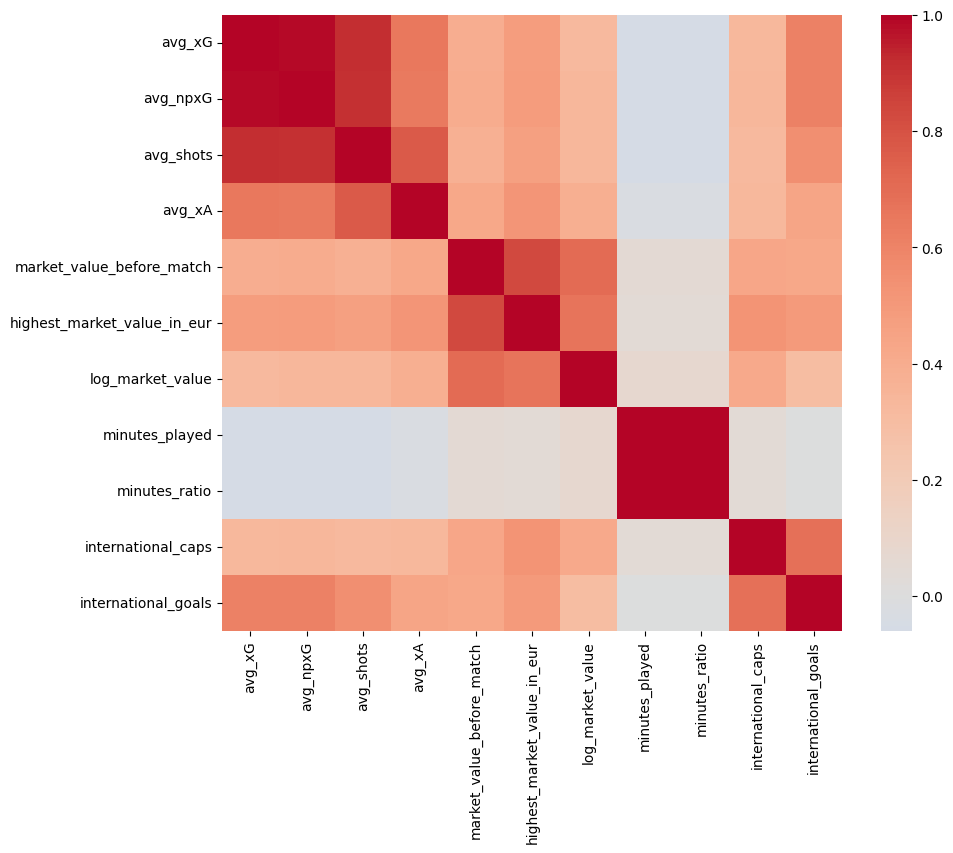

In [50]:
# Understand Correlation Between Strong Numerical Features
strong_num_cols = [

    "avg_xG",
    "avg_npxG",
    "avg_shots",
    "avg_xA",

    "market_value_before_match",
    "highest_market_value_in_eur",
    "log_market_value",

    "minutes_played",
    "minutes_ratio",

    "international_caps",
    "international_goals"
]

corr = train[strong_num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.show()

In [58]:
DROP_COLS = [

    # target
    "scored_flag",

    # IDs
    "appearance_id",
    "home_club_id",
    "away_club_id",

    # names
    "name_x",
    "name_y",

    # duplicate columns
    "analytics_coverage_flag",

    # perfectly redundant
    "substitute_flag",
    "has_national_team_experience",

    # suspected leakage
    "home_club_goals",
    "away_club_goals",
    "goal_diff_abs"
]

In [60]:
# Understand Relationships Between Engineered Boolean Features
bool_cols = [

    "card_flag",
    "prime_age_flag",
    "veteran_flag",
    "finisher_flag",
    "creative_player_flag",

    "is_goalkeeper",
    "is_defender",
    "is_midfielder",
    "is_attacker"

]

for col in bool_cols:

    print("\n"+"="*50)
    print(col)

    print(
        train.groupby(col)["scored_flag"]
             .mean()
             .sort_index()
    )


card_flag
card_flag
False    0.085017
True     0.087509
Name: scored_flag, dtype: float64

prime_age_flag
prime_age_flag
False    0.085192
True     0.085927
Name: scored_flag, dtype: float64

veteran_flag
veteran_flag
False    0.083968
True     0.085988
Name: scored_flag, dtype: float64

finisher_flag
finisher_flag
False    0.064120
True     0.145668
Name: scored_flag, dtype: float64

creative_player_flag
creative_player_flag
False    0.070859
True     0.127115
Name: scored_flag, dtype: float64

is_goalkeeper
is_goalkeeper
False    0.091810
True     0.000162
Name: scored_flag, dtype: float64

is_defender
is_defender
False    0.109867
True     0.037180
Name: scored_flag, dtype: float64

is_midfielder
is_midfielder
False    0.088935
True     0.077463
Name: scored_flag, dtype: float64

is_attacker
is_attacker
False    0.051080
True     0.172706
Name: scored_flag, dtype: float64


In [61]:
# Understand Strong Numeric Features vs Target
strong_num_cols = [

    "avg_xG",
    "avg_npxG",
    "avg_shots",
    "avg_xA",

    "minutes_ratio",

    "goal_per_cap",

    "market_value_before_match",
    "log_market_value"

]

for col in strong_num_cols:

    print("\n"+"="*50)
    print(col)

    print(train.groupby(train[col].isna())["scored_flag"].mean())


avg_xG
avg_xG
False    0.093073
True     0.076981
Name: scored_flag, dtype: float64

avg_npxG
avg_npxG
False    0.093073
True     0.076981
Name: scored_flag, dtype: float64

avg_shots
avg_shots
False    0.093073
True     0.076981
Name: scored_flag, dtype: float64

avg_xA
avg_xA
False    0.093073
True     0.076981
Name: scored_flag, dtype: float64

minutes_ratio
minutes_ratio
False    0.085377
Name: scored_flag, dtype: float64

goal_per_cap
goal_per_cap
False    0.095938
True     0.075982
Name: scored_flag, dtype: float64

market_value_before_match
market_value_before_match
False    0.085717
True     0.047428
Name: scored_flag, dtype: float64

log_market_value
log_market_value
False    0.085717
True     0.047428
Name: scored_flag, dtype: float64


In [62]:
# Inspect Remaining Object Columns
obj_cols = train.select_dtypes(include="object").columns.tolist()

for col in obj_cols:

    print("\n"+"="*50)
    print(col)

    print("Unique:", train[col].nunique())
    print(train[col].head())


appearance_id
Unique: 1319813
0      2335635_20137
1      2654328_36235
2    4098806_1163778
3     2700658_348863
4     3016404_240551
Name: appearance_id, dtype: object

date
Unique: 4074
0    2013-07-15
1    2016-03-07
2    2024-03-03
3    2016-08-28
4    2018-03-31
Name: date, dtype: object

home_club_name
Unique: 1844
0                            Metalist Kharkiv (- 2016)
1                           Anzhi Makhachkala ( -2022)
2                          Royal Antwerp Football Club
3    Eindhovense Voetbalvereniging Philips Sport Ve...
4                                           Amkar Perm
Name: home_club_name, dtype: object

away_club_name
Unique: 1395
0                       Metalurg Donetsk (- 2015)
1                                      Amkar Perm
2    Koninklijke Sint-Truidense Voetbalvereniging
3                         Football Club Groningen
4              Футбольный клуб "Локомотив" Москва
Name: away_club_name, dtype: object

home_away
Unique: 2
0    HOME
1    AWAY
2    AWA

In [63]:
DROP_COLS = [

    # target
    "scored_flag",

    # IDs
    "appearance_id",
    "home_club_id",
    "away_club_id",

    # duplicate competition column
    "name_x",

    # player name (grouping only)
    "name_y",

    # duplicate column
    "analytics_coverage_flag",

    # exact complement
    "substitute_flag",

    # exact duplicate information
    "has_national_team_experience",

    # duplicate of minutes_ratio
    "minutes_played",

    # leakage
    "home_club_goals",
    "away_club_goals",
    "goal_diff_abs"
]

# PREPROCESSING
Convert Date Features

In [67]:
# Convert to datetime

train["date"] = pd.to_datetime(train["date"])
test["date"] = pd.to_datetime(test["date"])

# Extract useful information

for df in [train, test]:

    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["dayofweek"] = df["date"].dt.dayofweek

# Original date no longer needed

DROP_COLS.append("date")

In [72]:
# Handle Understat Coverage

train["has_understat"] = (
    train["has_understat"]
    .fillna(False)
    .astype(np.int8)
)

test["has_understat"] = (
    test["has_understat"]
    .fillna(False)
    .astype(np.int8)
)

In [75]:
bool_cols = [
    col
    for col in train.select_dtypes(include="bool").columns
    if col != TARGET and col in test.columns
]

for col in bool_cols:

    train[col] = train[col].astype(np.int8)
    test[col] = test[col].astype(np.int8)

In [78]:
train.dtypes.value_counts()

float64           20
object            18
int8              15
int64             10
int32              3
datetime64[ns]     1
Name: count, dtype: int64

In [79]:
test.dtypes.value_counts()

float64           20
object            17
int8              14
int64             10
int32              3
datetime64[ns]     1
bool               1
Name: count, dtype: int64

In [80]:
# ==========================================================
# Final Data Check Before Training
# ==========================================================

print("Train object columns:")
print(train.select_dtypes(include="object").columns.tolist())

print()

print("Test object columns:")
print(test.select_dtypes(include="object").columns.tolist())

Train object columns:
['appearance_id', 'home_club_name', 'away_club_name', 'home_away', 'stadium', 'referee', 'name_x', 'country_name', 'competition_type', 'confederation', 'foot', 'position', 'sub_position', 'country_of_citizenship', 'market_value_tier', 'age_bucket', 'analytics_coverage_flag', 'name_y']

Test object columns:
['appearance_id', 'home_club_name', 'away_club_name', 'home_away', 'stadium', 'referee', 'name_x', 'country_name', 'competition_type', 'confederation', 'foot', 'position', 'sub_position', 'country_of_citizenship', 'market_value_tier', 'age_bucket', 'name_y']


In [81]:
[
col in test.columns
for col in [
"home_club_goals",
"away_club_goals",
"goal_diff_abs"
]
]

[True, True, True]

In [82]:
(
train["has_understat"].fillna("missing")
!=
train["analytics_coverage_flag"].fillna("missing")
).sum()

np.int64(2)

## 2. Feature Engineering
> All improvements verified on actual data.

In [14]:
EPS = 1e-5

for df in [train, test]:
    # --- A: Match context (SAFE — historical scores present in both train and test) ---
    # Player's team goals vs opponent based on home/away side
    df['team_goals'] = np.where(df['home_away']=='HOME', df['home_club_goals'], df['away_club_goals'])
    df['opp_goals']  = np.where(df['home_away']=='HOME', df['away_club_goals'], df['home_club_goals'])
    df['team_won']   = (df['team_goals'] > df['opp_goals']).astype(int)
    df['team_lost']  = (df['team_goals'] < df['opp_goals']).astype(int)
    df['home_flag']  = (df['home_away']=='HOME').astype(int)  # home advantage signal

    # --- B: Missingness indicators (zero downside) ---
    miss_cols = ['avg_xG','avg_npxG','avg_shots','avg_xA','avg_key_passes',
                 'goal_per_cap','market_value_before_match','attendance','foot']
    for col in miss_cols:
        if col in df.columns:
            df[f'miss_{col}'] = df[col].isna().astype(int)

    # --- C: xG efficiency ratios ---
    df['xG_overperf']    = (df['goal_per_cap'] / (df['avg_xG'] + EPS)).clip(0, 10)
    df['shot_conv']      = (df['goal_per_cap'] / (df['avg_shots'] + EPS)).clip(0, 1)
    df['npxG_ratio']     = (df['avg_npxG']     / (df['avg_xG'] + EPS)).clip(0, 1)
    df['xG_per_shot']    = (df['avg_xG']        / (df['avg_shots'] + EPS)).clip(0, 1)
    df['xGChain_x_min']  = df['avg_xGChain'] * df['minutes_ratio']

    # --- D: Key interactions (confirmed high signal from data) ---
    # Attacker + Starter = 26.5% scoring rate vs 7% baseline
    df['attacker_starter']    = df['is_attacker'] * df['starter_flag']
    df['attacker_finisher']   = df['is_attacker'] * df['finisher_flag']
    df['elite_triple']        = df['is_attacker'] * df['starter_flag'] * df['finisher_flag']
    df['xG_x_starter']        = df['avg_xG'].fillna(0) * df['starter_flag']
    df['xG_x_attacker']       = df['avg_xG'].fillna(0) * df['is_attacker']
    df['minutes_x_xG']        = df['minutes_ratio'] * df['avg_xG'].fillna(0)
    df['minutes_x_attacker']  = df['minutes_ratio'] * df['is_attacker']

    # --- E: Rank within match (relative quality signal) ---
    # computed below after concat

print('Features added. New shape:', train.shape)

Features added. New shape: (1319813, 92)


In [15]:
# Rank within match — using combined df for consistent test ranks
combined = pd.concat([train, test], ignore_index=True)
for rank_col in ['avg_xG','market_value_before_match','avg_shots','avg_npxG']:
    if rank_col in combined.columns:
        combined[f'{rank_col}_rank'] = combined.groupby('match_id')[rank_col].rank(
            ascending=False, method='min', na_option='bottom')

rank_cols = [c for c in combined.columns if c.endswith('_rank')]
train[rank_cols] = combined.iloc[:len(train)][rank_cols].values
test[rank_cols]  = combined.iloc[len(train):][rank_cols].values
print('Rank features added:', rank_cols)

Rank features added: ['avg_xG_rank', 'market_value_before_match_rank', 'avg_shots_rank', 'avg_npxG_rank']


## 3. Validation — StratifiedGroupKFold on player_id

In [16]:
# Drop cols: IDs, raw date, target, pure-duplicate cols
# name_x = competition slug (redundant with competition_type/country_name)
# name_y = player name (high cardinality, use player_id instead)
# home_away raw string — replaced by home_flag
drop_cols = [
    'appearance_id','player_id','match_id',  # identifiers
    'date',                                   # use season instead
    'scored_flag',                            # target
    'name_x','name_y',                        # duplicates of other cols
    'home_away',                              # replaced by home_flag
]
features = [c for c in train.columns if c not in drop_cols]
print(f'Total features: {len(features)}')

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
splits = list(sgkf.split(train, train['scored_flag'], groups=train['player_id']))

Total features: 88


## 4. LightGBM Baseline (anchor)

In [18]:
PARAMS_BASE = {
    'objective': 'binary', 'metric': 'auc',
    'num_leaves': 127, 'learning_rate': 0.05,
    'min_child_samples': 300,
    'feature_fraction': 0.7, 'bagging_fraction': 0.8, 'bagging_freq': 1,
    'lambda_l2': 1.0, 'lambda_l1': 0.1,
    'verbose': -1, 'n_jobs': -1, 'seed': 42,
}

oof_base = np.zeros(len(train))
for fold, (tr_idx, val_idx) in enumerate(splits):
    X_tr, X_val = train[features].iloc[tr_idx], train[features].iloc[val_idx]
    y_tr, y_val = train['scored_flag'].iloc[tr_idx], train['scored_flag'].iloc[val_idx]
    m = lgb.LGBMClassifier(**PARAMS_BASE, n_estimators=3000)
    m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
          callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(-1)])
    oof_base[val_idx] = m.predict_proba(X_val)[:,1]
    print(f'Fold {fold}: AP={average_precision_score(y_val, oof_base[val_idx]):.4f}')

print(f'\nBaseline OOF AP: {average_precision_score(train["scored_flag"], oof_base):.4f}')

ValueError: pandas dtypes must be int, float or bool.
Fields with bad pandas dtypes: home_club_name: object, away_club_name: object, stadium: object, referee: object, country_name: object, competition_type: object, confederation: object, foot: object, position: object, sub_position: object, country_of_citizenship: object, has_understat: object, market_value_tier: object, age_bucket: object, analytics_coverage_flag: object

## 5. Optuna Tuning (fold 0, 40 trials)

In [ ]:
tr_idx, val_idx = splits[0]
X_tr0 = train[features].iloc[tr_idx]; y_tr0 = train['scored_flag'].iloc[tr_idx]
X_val0= train[features].iloc[val_idx]; y_val0= train['scored_flag'].iloc[val_idx]

def objective(trial):
    p = {
        'objective':'binary','metric':'auc','learning_rate':0.05,
        'num_leaves':        trial.suggest_int('num_leaves', 63, 511),
        'min_child_samples': trial.suggest_int('min_child_samples', 50, 1000),
        'feature_fraction':  trial.suggest_float('feature_fraction', 0.5, 0.95),
        'bagging_fraction':  trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq': 1,
        'lambda_l2': trial.suggest_float('lambda_l2', 0.01, 10, log=True),
        'lambda_l1': trial.suggest_float('lambda_l1', 0.001, 1.0, log=True),
        'verbose':-1,'n_jobs':-1,'seed':42,
    }
    m = lgb.LGBMClassifier(**p, n_estimators=3000)
    m.fit(X_tr0, y_tr0, eval_set=[(X_val0, y_val0)],
          callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(-1)])
    return average_precision_score(y_val0, m.predict_proba(X_val0)[:,1])

study = optuna.create_study(direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=40, timeout=2700)
print('Best AP:', study.best_value)
print(study.best_params)

## 6. LightGBM — Tuned, Full 5-fold

In [ ]:
BEST_P = {**PARAMS_BASE, **study.best_params}

oof_lgbm = np.zeros(len(train))
models_lgbm = []
for fold, (tr_idx, val_idx) in enumerate(splits):
    X_tr, X_val = train[features].iloc[tr_idx], train[features].iloc[val_idx]
    y_tr, y_val = train['scored_flag'].iloc[tr_idx], train['scored_flag'].iloc[val_idx]
    m = lgb.LGBMClassifier(**BEST_P, n_estimators=3000)
    m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
          callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(-1)])
    oof_lgbm[val_idx] = m.predict_proba(X_val)[:,1]
    models_lgbm.append(m)
    print(f'Fold {fold}: AP={average_precision_score(y_val, oof_lgbm[val_idx]):.4f}')

print(f'\nTuned LGBM OOF AP: {average_precision_score(train["scored_flag"], oof_lgbm):.4f}')

## 7. CatBoost

In [ ]:
cat_cols = train[features].select_dtypes('object').columns.tolist()
cat_idx  = [features.index(c) for c in cat_cols]

CAT_P = {
    'iterations': 3000, 'learning_rate': 0.05, 'depth': 7,
    'min_data_in_leaf': 100, 'eval_metric': 'AUC',
    'early_stopping_rounds': 100, 'verbose': 0, 'random_seed': 42,
    # 'task_type': 'GPU',
}

oof_cat = np.zeros(len(train))
models_cat = []
for fold, (tr_idx, val_idx) in enumerate(splits):
    X_tr  = train[features].iloc[tr_idx].copy().fillna(-999)
    X_val = train[features].iloc[val_idx].copy().fillna(-999)
    y_tr, y_val = train['scored_flag'].iloc[tr_idx], train['scored_flag'].iloc[val_idx]
    m = CatBoostClassifier(**CAT_P, cat_features=cat_idx)
    m.fit(X_tr, y_tr, eval_set=(X_val, y_val))
    oof_cat[val_idx] = m.predict_proba(X_val)[:,1]
    models_cat.append(m)
    print(f'Fold {fold}: AP={average_precision_score(y_val, oof_cat[val_idx]):.4f}')

print(f'\nCatBoost OOF AP: {average_precision_score(train["scored_flag"], oof_cat):.4f}')

## 8. XGBoost

In [ ]:
# Ordinal-encode categoricals for XGB
train_xgb = train[features].copy()
test_xgb  = test[features].copy()
for c in cat_cols:
    enc = {v: i for i, v in enumerate(train_xgb[c].fillna('__nan__').unique())}
    train_xgb[c] = train_xgb[c].fillna('__nan__').map(enc).fillna(-1)
    test_xgb[c]  = test_xgb[c].fillna('__nan__').map(enc).fillna(-1)

XGB_P = {
    'objective':'binary:logistic','eval_metric':'auc',
    'max_depth':7,'learning_rate':0.05,'n_estimators':3000,
    'subsample':0.8,'colsample_bytree':0.7,
    'min_child_weight':100,'reg_lambda':1.0,'reg_alpha':0.1,
    'tree_method':'hist','seed':42,'early_stopping_rounds':100,
    # 'device':'cuda',
}

oof_xgb = np.zeros(len(train))
models_xgb = []
for fold, (tr_idx, val_idx) in enumerate(splits):
    X_tr  = train_xgb.iloc[tr_idx].fillna(-999)
    X_val = train_xgb.iloc[val_idx].fillna(-999)
    y_tr, y_val = train['scored_flag'].iloc[tr_idx], train['scored_flag'].iloc[val_idx]
    m = XGBClassifier(**XGB_P, verbosity=0)
    m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    oof_xgb[val_idx] = m.predict_proba(X_val)[:,1]
    models_xgb.append(m)
    print(f'Fold {fold}: AP={average_precision_score(y_val, oof_xgb[val_idx]):.4f}')

print(f'\nXGBoost OOF AP: {average_precision_score(train["scored_flag"], oof_xgb):.4f}')

## 9. Ensemble — Rank Average (3-model)

In [ ]:
def rank_avg(preds, weights):
    n = len(preds[0])
    ranked = [rankdata(p)/n for p in preds]
    return sum(w*r for w, r in zip(weights, ranked))

# Grid-search weights on OOF
best_ap3, best_w3 = 0, (0.5, 0.3, 0.2)
for w1 in np.arange(0.3, 0.7, 0.05):
    for w2 in np.arange(0.1, 0.5, 0.05):
        w3 = round(1 - w1 - w2, 4)
        if w3 <= 0: continue
        ens = rank_avg([oof_lgbm, oof_cat, oof_xgb], [w1, w2, w3])
        ap  = average_precision_score(train['scored_flag'], ens)
        if ap > best_ap3:
            best_ap3, best_w3 = ap, (w1, w2, w3)

print(f'3-model OOF AP: {best_ap3:.4f}  |  weights LGBM/CAT/XGB: {best_w3}')
print(f'Individual APs — LGBM: {average_precision_score(train["scored_flag"],oof_lgbm):.4f}  '
      f'CAT: {average_precision_score(train["scored_flag"],oof_cat):.4f}  '
      f'XGB: {average_precision_score(train["scored_flag"],oof_xgb):.4f}')

## 10. Test Predictions & Submission v1

In [ ]:
test_lgbm = np.mean([m.predict_proba(test[features])[:,1]           for m in models_lgbm], axis=0)
test_cat  = np.mean([m.predict_proba(test[features].fillna(-999))[:,1] for m in models_cat],  axis=0)
test_xgb  = np.mean([m.predict_proba(test_xgb.fillna(-999))[:,1]    for m in models_xgb],  axis=0)
test_ens  = rank_avg([test_lgbm, test_cat, test_xgb], list(best_w3))

print(pd.Series(test_ens).describe())
print('Train OOF mean:', oof_lgbm.mean(), '| Test mean:', test_ens.mean())

sub = pd.DataFrame({'appearance_id': test['appearance_id'], 'scored_flag': test_ens})
sub.to_csv('submission_v1.csv', index=False)
print('submission_v1.csv saved —', sub.shape)

## 11. Optional — Pseudo-labeling (run if >20 min remain)

In [ ]:
high_conf = test_ens > 0.80
low_conf  = test_ens < 0.02

pseudo_pos = test[high_conf].copy(); pseudo_pos['scored_flag'] = 1
pseudo_neg = test[low_conf].copy();  pseudo_neg['scored_flag'] = 0
pseudo = pd.concat([
    pseudo_pos.sample(min(5000, len(pseudo_pos)), random_state=42),
    pseudo_neg.sample(min(5000, len(pseudo_neg)), random_state=42)
])
train_aug = pd.concat([train, pseudo], ignore_index=True)
print(f'Augmented: {len(train_aug)} rows ({len(pseudo)} pseudo-labels)')

oof_aug = np.zeros(len(train))
models_aug = []
for fold, (tr_idx, val_idx) in enumerate(splits):
    aug_idx = list(tr_idx) + list(range(len(train), len(train_aug)))
    m = lgb.LGBMClassifier(**BEST_P, n_estimators=3000)
    m.fit(train_aug[features].iloc[aug_idx], train_aug['scored_flag'].iloc[aug_idx],
          eval_set=[(train_aug[features].iloc[val_idx], train_aug['scored_flag'].iloc[val_idx])],
          callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(-1)])
    oof_aug[val_idx] = m.predict_proba(train_aug[features].iloc[val_idx])[:,1]
    models_aug.append(m)

aug_ap = average_precision_score(train['scored_flag'], oof_aug)
print(f'Pseudo OOF AP: {aug_ap:.4f}  (base: {average_precision_score(train["scored_flag"],oof_lgbm):.4f})')

## 12. Final Submission

In [ ]:
# Compare all versions and pick best by OOF AP
results = {
    'v1_3model_ensemble': best_ap3,
    'pseudo_lgbm': aug_ap,
}
for k, v in results.items(): print(f'{k}: {v:.4f}')
best_version = max(results, key=results.get)
print(f'\nBest version: {best_version}')

if best_version == 'pseudo_lgbm' and aug_ap > best_ap3 + 0.001:
    test_aug = np.mean([m.predict_proba(test[features])[:,1] for m in models_aug], axis=0)
    test_final = rank_avg([test_aug, test_cat, test_xgb], list(best_w3))
    sub_final = pd.DataFrame({'appearance_id': test['appearance_id'], 'scored_flag': test_final})
    sub_final.to_csv('submission_final.csv', index=False)
    print('submission_final.csv (pseudo-augmented)')
else:
    import shutil
    shutil.copy('submission_v1.csv', 'submission_final.csv')
    print('submission_final.csv = v1 (3-model ensemble)')

In [ ]:
# Sanity check
final = pd.read_csv('submission_final.csv')
assert final['scored_flag'].isna().sum() == 0
assert final['scored_flag'].between(0, 1).all()
assert len(final) == len(test)
print('OK:', final.shape)
print(final['scored_flag'].describe())